# Qwen2-VL — Fine-Tuning on `pedestrianqa_egypt_from_demographics.csv` + GPT-Augmented Data (Cross-Validated)

**This is a cleaned rebuild of the working notebook** -- your CSV-merge and
SYN-path-remapping work is preserved, plus five fixes:

1. **The `§11` cell that actually computes `ft_acc`/`ft_f1` had gone missing**
   somewhere during editing -- `§12`/`§13` referenced it but nothing defined
   it. Restored, and extended with a **real vs. synthetic breakdown** (see
   point 3).
2. **Honest system prompt.** It previously told the model *"you are given
   three sequential frames"* unconditionally, even for `SYN_` tracks that
   only have one real image (padded to 3 by duplicating it). The prompt now
   describes what's actually being shown, per example.
3. **Strict, trackable answer parsing.** Training targets now end with an
   unambiguous `FINAL_ANSWER: Yes`/`FINAL_ANSWER: No` line (built from the
   reliable `answer` column, not free text), the system prompt instructs the
   model to always end with that line, and `parse_label()` looks for it
   first -- falling back to the old keyword heuristic only when it's
   missing, and **counting how often that happens** so parsing failure rate
   is visible instead of silently defaulting to "No".
4. **`source` column (real / synthetic)** added, with before/after accuracy
   reported separately for each in `§11` -- don't trust the pooled n≈94
   number until you've checked these aren't wildly different from each
   other.
5. **Frame-aware CoT (v5).** `spatial_reasoning`/`temporal_reasoning`/
   `mathematical_reasoning` are now excluded from the training target for any
   row with a single real source image (the `SYN_` tracks) -- those fields
   can't be legitimately inferred from one static frame, and training on them
   was noisy, input-inconsistent supervision. See `§3` for detail.

Also removed: a fully-commented-out duplicate hyperparameters cell, a second
duplicate relocated under `§10`, and a commented-out duplicate of the entire
CV loop -- all harmless individually but confusing to read and a sign the
notebook had drifted from something you could trust to "run all" cleanly.

## §0 — Install Dependencies

In [ ]:
!pip install torch torchvision --quiet
!pip install transformers accelerate peft trl bitsandbytes --quiet
!pip install scikit-learn pandas numpy matplotlib pillow --quiet
print("Dependencies installed ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 885.0/885.0 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 54.3 MB/s eta 0:00:00
Dependencies installed ✓


## §1 — Imports & Global Config

In [ ]:
import os, gc, re, time, warnings, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import (
    Qwen2VLForConditionalGeneration, Qwen2VLProcessor,
    BitsAndBytesConfig, TrainingArguments, Trainer, EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

warnings.filterwarnings('ignore')
os.environ["WANDB_DISABLED"] = "true"

SEED = 42
def set_seed(s=SEED):
    import random; random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}  |  PyTorch: {torch.__version__}")

Device: cuda  |  PyTorch: 2.11.0+cu128


## §2 — Paths, Hyperparameters & Dataset Merge

In [ ]:
from google.colab import drive
if not os.path.isdir('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

# ── Base dataset (demographics-derived, 30 real tracks) ────────────────────
CSV_PATH_LOCAL = '/content/pedestrianqa_egypt_from_demographics.csv'
CSV_PATH_DRIVE = '/content/drive/MyDrive/PedestrianQA_Egypt_output/pedestrianqa_egypt_from_demographics.csv'

if os.path.isfile(CSV_PATH_LOCAL):
    CSV_PATH = CSV_PATH_LOCAL
elif os.path.isfile(CSV_PATH_DRIVE):
    CSV_PATH = CSV_PATH_DRIVE
else:
    from google.colab import files
    print('CSV not found locally or on Drive — please upload pedestrianqa_egypt_from_demographics.csv')
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
print(f"Using CSV: {CSV_PATH}")

# ── GPT-augmented dataset (SYN_ tracks, synthetic images) ──────────────────
GPT_CSV_PATH_LOCAL = '/content/pedestrianqa_egypt_gpt_augmented.csv'
GPT_CSV_PATH_DRIVE = '/content/drive/MyDrive/PedestrianQA_Egypt_output/pedestrianqa_egypt_gpt_augmented - pedestrianqa_egypt_gpt_finetuning.csv'
if os.path.isfile(GPT_CSV_PATH_LOCAL):
    GPT_CSV_PATH = GPT_CSV_PATH_LOCAL
elif os.path.isfile(GPT_CSV_PATH_DRIVE):
    GPT_CSV_PATH = GPT_CSV_PATH_DRIVE
else:
    GPT_CSV_PATH = None

if GPT_CSV_PATH:
    df_base = pd.read_csv(CSV_PATH)
    df_gpt = pd.read_csv(GPT_CSV_PATH)
    df_raw = pd.concat([df_base, df_gpt], ignore_index=True)
    print(f"Base dataset:          {len(df_base)} rows")
    print(f"GPT-augmented dataset: {len(df_gpt)} rows")
    print(f"Merged total:          {len(df_raw)} rows ✓")
else:
    df_raw = pd.read_csv(CSV_PATH)
    print(f"⚠️  GPT-augmented CSV not found — running on base dataset only ({len(df_raw)} rows).")

DRIVE_PREFIX_OLD = '/content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2'
DRIVE_PREFIX_NEW = '/content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2'

OUTPUT_DIR = '/content/output/qwen_pedestrianqa_egypt'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Model & training hyperparameters ─────────────────────────────────────
MODEL_ID       = 'Qwen/Qwen2-VL-7B-Instruct'
EPOCHS         = 6
BATCH_SIZE     = 1
GRAD_ACCUM     = 4
LEARNING_RATE  = 1e-4
MAX_SEQ_LEN    = 2048          # room for the longer FINAL_ANSWER-terminated targets
WARMUP_STEPS   = 10
MAX_GRAD_NORM  = 1.0
LORA_R         = 16
LORA_ALPHA     = 32
LORA_DROPOUT   = 0.05
MAX_NEW_TOKENS = 450

K_FOLDS = 5

MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 512 * 28 * 28
MAX_IMAGE_SIDE = 640

print("Hyperparameters set ✓")

Mounted at /content/drive
Using CSV: /content/drive/MyDrive/PedestrianQA_Egypt_output/pedestrianqa_egypt_from_demographics.csv
Base dataset:          30 rows
GPT-augmented dataset: 72 rows
Merged total:          102 rows ✓
Hyperparameters set ✓


## §3 — Data Loading

Adds two things beyond what you had: a `source` column (`real` vs
`synthetic`, by `track_id` prefix) used for the breakdown in `§11`, and a
`FINAL_ANSWER:` sentinel appended to every training target (built straight
from the reliable `answer` column, not the free-text `conclusion`, so it
can never be wrong or ambiguous).

**v5 update:** `build_cot_target()` is now frame-aware. Rows with only one real source image (`n_raw_images < 2` -- the GPT-augmented `SYN_` tracks, duplicated to 3 for the collator) now only get `age/gender/attention/judgment/position/appearance/physical` reasoning in the training target. `spatial_reasoning`, `temporal_reasoning`, and `mathematical_reasoning` are dropped for those rows, since they describe frame-to-frame motion (velocity, displacement, timing) that a single static frame can't support -- that mismatch between what the model was shown and what it was asked to confidently narrate was likely capping fine-tuned accuracy around 66-68%. Real multi-frame tracks are unaffected and keep the full field set.

In [ ]:
def remap_path(p):
    p = p.strip()
    if '/EgyptPedestriansDataset/gpt_augmented/images' in p:
        p = p.replace(
            '/content/drive/MyDrive/EgyptPedestriansDataset/gpt_augmented/images',
            '/content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2/gpt_augmented/images'
        )
    elif '/EgyptPedestriansDataset_v2/gpt_augmented/images' in p and 'GIU.Master' not in p:
        p = p.replace(
            '/content/drive/MyDrive/EgyptPedestriansDataset_v2/gpt_augmented/images',
            '/content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2/gpt_augmented/images'
        )
    elif DRIVE_PREFIX_OLD != DRIVE_PREFIX_NEW:
        p = p.replace(DRIVE_PREFIX_OLD, DRIVE_PREFIX_NEW)
    return p

# Reasoning categories that are inferable from ANY single static frame.
SINGLE_FRAME_REASONING_COLS = [
    'age_reasoning', 'gender_reasoning', 'attention_reasoning', 'judgment_reasoning',
    'position_reasoning', 'appearance_reasoning', 'physical_reasoning',
]

# Categories that inherently require comparing >=2 distinct frames (velocity,
# displacement, frame-to-frame movement, observation-window timing). Only valid
# supervision when the row truly has multiple distinct source images -- the same
# n_raw_images >= 2 condition already used for the `sequential` system-prompt flag
# elsewhere in this notebook. For single-image rows (duplicated to 3 for the
# collator), these fields would describe motion the model was never actually
# shown -- the inconsistent-supervision issue flagged in the accuracy review.
MULTI_FRAME_REASONING_COLS = ['spatial_reasoning', 'temporal_reasoning', 'mathematical_reasoning']

ALL_REASONING_COLS = SINGLE_FRAME_REASONING_COLS + MULTI_FRAME_REASONING_COLS
REASONING_LABEL_MAP = {c: c.replace('_reasoning', '').capitalize() for c in ALL_REASONING_COLS}

def build_cot_target(row) -> str:
    '''Builds the CoT training target. Rows with a single real source image
    (n_raw_images < 2, i.e. synthetic/GPT-augmented tracks) only get the
    single-frame-observable reasoning fields -- spatial/temporal/mathematical
    reasoning is dropped for them since it can't legitimately be inferred from
    one static frame. Real multi-frame tracks keep the full field set, since
    they genuinely have 3 distinct frames to reason about motion across.'''
    is_sequential = row['n_raw_images'] >= 2
    cols = ALL_REASONING_COLS if is_sequential else SINGLE_FRAME_REASONING_COLS
    parts = [f"{REASONING_LABEL_MAP[col]}: {row[col]}" for col in cols]
    parts.append(f"Conclusion: {row['conclusion']}")
    # Strict, unambiguous sentinel built from the reliable label column --
    # this is what parse_label() looks for first at inference time.
    parts.append(f"FINAL_ANSWER: {str(row['answer']).strip()}")
    return ' '.join(parts)

df = df_raw.copy()
df['n_raw_images'] = df['images'].apply(lambda s: len(str(s).split(';')))
df['image_paths']  = df['images'].apply(lambda s: [remap_path(p) for p in str(s).split(';')])
df['label_bin']    = (df['answer'].str.strip().str.lower() == 'yes').astype(int)
df['cot_target']   = df.apply(build_cot_target, axis=1)
df['source']       = np.where(df['track_id'].str.startswith('SYN_'), 'synthetic', 'real')

def all_images_exist(paths):
    return all(os.path.isfile(p) for p in paths)

df['images_ok'] = df['image_paths'].apply(all_images_exist)
n_missing = (~df['images_ok']).sum()
if n_missing:
    missing_ids = df[~df['images_ok']]['track_id'].tolist()
    print(f"⚠️  Dropping {n_missing} tracks with missing images: {missing_ids}")
df = df[df['images_ok']].reset_index(drop=True)

n_real = (df['source'] == 'real').sum()
n_syn = (df['source'] == 'synthetic').sum()
print(f"Final usable tracks: {len(df)}  (real={n_real}, synthetic={n_syn})")
print(df['answer'].value_counts())

# Sanity-check: confirm the CoT trimming happened as intended, and eyeball one
# example of each so a bad merge/regeneration doesn't silently slip through.
n_trimmed = int((df['n_raw_images'] < 2).sum())
n_full = int((df['n_raw_images'] >= 2).sum())
print(f"\nCoT fields -- full/sequential (n={n_full}): {ALL_REASONING_COLS}")
print(f"CoT fields -- trimmed/single-frame (n={n_trimmed}): {SINGLE_FRAME_REASONING_COLS}")
if n_trimmed:
    print("\nExample TRIMMED target (single-frame row):")
    print(textwrap.fill(df.loc[df['n_raw_images'] < 2, 'cot_target'].iloc[0], width=100))
if n_full:
    print("\nExample FULL target (sequential row):")
    print(textwrap.fill(df.loc[df['n_raw_images'] >= 2, 'cot_target'].iloc[0], width=100))

df[['track_id', 'source', 'answer', 'label_bin', 'n_raw_images']].head()


⚠️  Dropping 8 tracks with missing images: ['SYN_0008', 'SYN_0010', 'SYN_0014', 'SYN_0024', 'SYN_0068', 'SYN_0069', 'SYN_0070', 'SYN_0071']
Final usable tracks: 94  (real=30, synthetic=64)
answer
Yes    58
No     36
Name: count, dtype: int64

CoT fields -- full/sequential (n=30): ['age_reasoning', 'gender_reasoning', 'attention_reasoning', 'judgment_reasoning', 'position_reasoning', 'appearance_reasoning', 'physical_reasoning', 'spatial_reasoning', 'temporal_reasoning', 'mathematical_reasoning']
CoT fields -- trimmed/single-frame (n=64): ['age_reasoning', 'gender_reasoning', 'attention_reasoning', 'judgment_reasoning', 'position_reasoning', 'appearance_reasoning', 'physical_reasoning']

Example TRIMMED target (single-frame row):
Age: The pedestrian appears to be a child, suggesting they may be less experienced in traffic
situations. Gender: The pedestrian is identified as male. Attention: The pedestrian is not
distracted according to the metadata. Judgment: The pedestrian made no hand 

,track_id,source,answer,label_bin,n_raw_images
0,V3_0,real,Yes,1,3
1,V3_6,real,Yes,1,3
2,V3_12,real,No,0,3
3,V3_13,real,Yes,1,3
4,V3_14,real,No,0,3


## §4 — Dataset Visualization

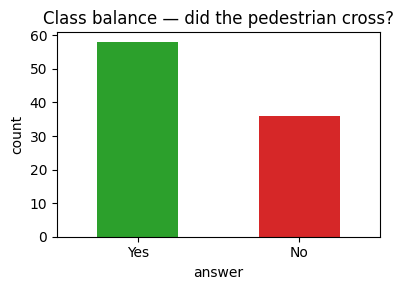

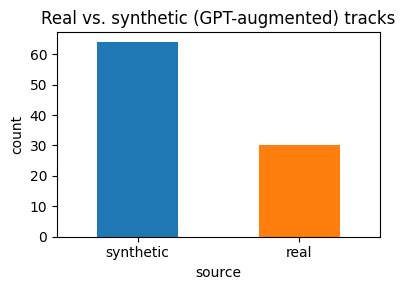

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))
df['answer'].value_counts().reindex(['Yes', 'No']).plot(
    kind='bar', color=['#2ca02c', '#d62728'], ax=ax)
ax.set_title('Class balance — did the pedestrian cross?')
ax.set_xlabel('answer'); ax.set_ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
df['source'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e'], ax=ax)
ax.set_title('Real vs. synthetic (GPT-augmented) tracks')
ax.set_xlabel('source'); ax.set_ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

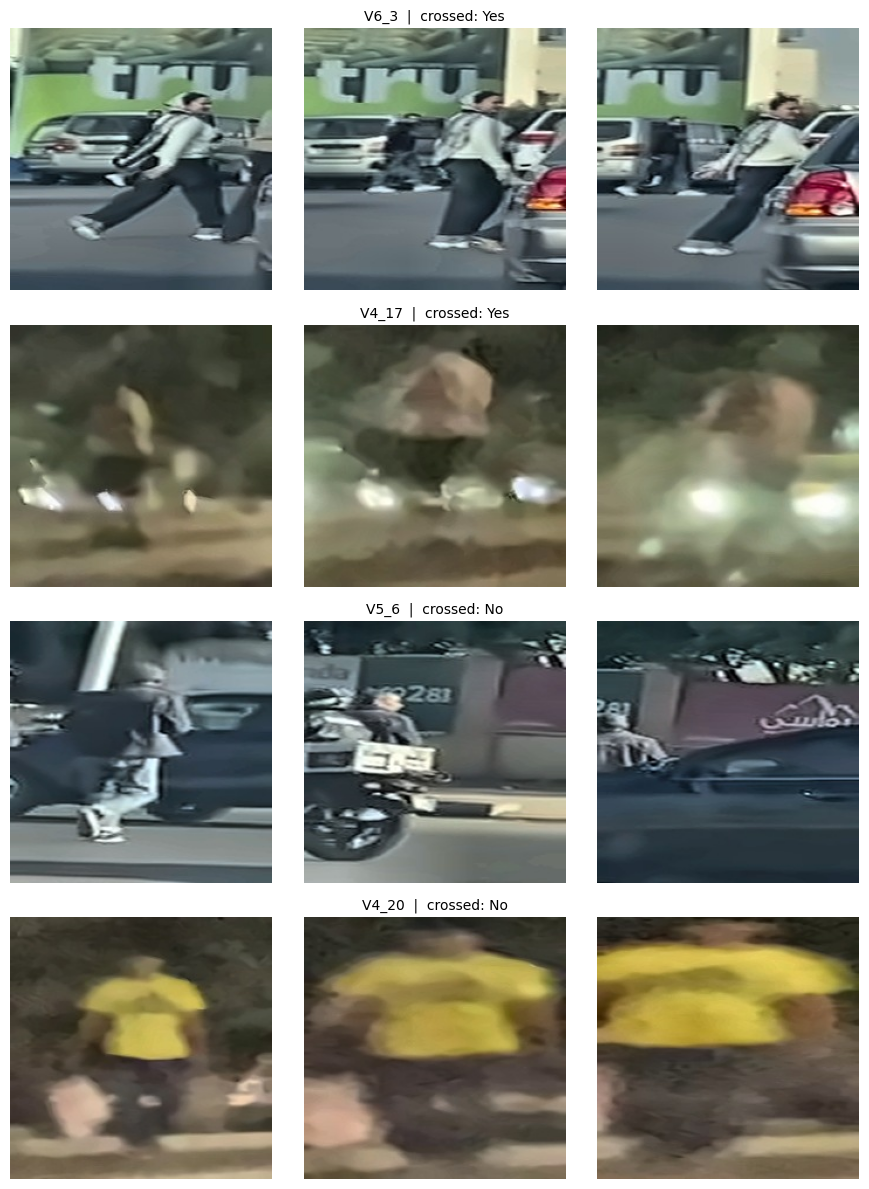

In [ ]:
# Montage: 3 frames each for a handful of real tracks (SYN rows have only 1 real image)
real_tracks = df[df['source'] == 'real'].reset_index(drop=True)
sample_tracks = real_tracks.sample(min(4, len(real_tracks)), random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(len(sample_tracks), 3, figsize=(9, 3 * len(sample_tracks)))
if len(sample_tracks) == 1:
    axes = axes[None, :]

for r, row in sample_tracks.iterrows():
    for c, img_path in enumerate(row['image_paths']):
        img = Image.open(img_path).convert('RGB')
        axes[r, c].imshow(img)
        axes[r, c].axis('off')
        if c == 1:
            axes[r, c].set_title(f"{row['track_id']}  |  crossed: {row['answer']}", fontsize=10)

plt.tight_layout(); plt.show()

## §5 — Conversation Format

`build_system_prompt()` now describes what's actually being shown --
`sequential=True` (real tracks, 3 distinct frames) gets the original
wording; `sequential=False` (SYN tracks, 1 image padded to 3 by
duplication) gets an honest description instead of the previous
unconditional "three sequential frames" claim. It also now explicitly
instructs the model to end with the `FINAL_ANSWER:` line.

In [ ]:
def build_system_prompt(sequential: bool) -> str:
    if sequential:
        frame_desc = ('You are given three sequential frames, each already cropped to a single '
                       'pedestrian at a road crossing.')
    else:
        frame_desc = ('You are given one frame, already cropped to a single pedestrian at a road '
                       'crossing (the same image is repeated to fill the three image slots below).')
    return (
        'You are a pedestrian crossing behaviour analyst for autonomous vehicles.\n'
        f'{frame_desc}\n'
        'Reason step by step using age, gender, attention, judgment, position, appearance, '
        'physical, spatial, temporal, and mathematical evidence, then give a concise conclusion '
        "stating whether the pedestrian crossed the road. End your entire response with exactly "
        "one line in the form 'FINAL_ANSWER: Yes' or 'FINAL_ANSWER: No', with nothing after it."
    )

def resize_image(img, max_side=MAX_IMAGE_SIDE):
    '''Downscale so the longer side is at most max_side px — keeps vision-token
    count (and therefore attention memory) bounded regardless of source resolution.'''
    w, h = img.size
    scale = max_side / max(w, h)
    if scale < 1.0:
        img = img.resize((max(1, int(w * scale)), max(1, int(h * scale))), Image.BICUBIC)
    return img

def load_images(paths):
    '''Load images from disk. For SYN rows the CSV has only one path;
    replicate it to 3 so the conversation builder always gets 3 images.'''
    imgs = [resize_image(Image.open(p).convert('RGB')) for p in paths]
    while len(imgs) < 3:
        imgs.append(imgs[-1])  # duplicate last frame for SYN single-image rows
    return imgs

def make_train_conversation(images, human_prompt, target_text, sequential=True) -> list:
    '''3-turn conversation for training (includes assistant answer).'''
    user_content = [{'type': 'image', 'image': img} for img in images]
    user_content.append({'type': 'text', 'text': human_prompt})
    return [
        {'role': 'system', 'content': [{'type': 'text', 'text': build_system_prompt(sequential)}]},
        {'role': 'user', 'content': user_content},
        {'role': 'assistant', 'content': [{'type': 'text', 'text': target_text}]},
    ]

def make_test_conversation(images, human_prompt, sequential=True) -> list:
    '''2-turn conversation for inference (no assistant turn).'''
    user_content = [{'type': 'image', 'image': img} for img in images]
    user_content.append({'type': 'text', 'text': human_prompt})
    return [
        {'role': 'system', 'content': [{'type': 'text', 'text': build_system_prompt(sequential)}]},
        {'role': 'user', 'content': user_content},
    ]

def df_to_train_convs(d):
    convs = []
    for _, row in d.iterrows():
        imgs = load_images(row['image_paths'])
        convs.append(make_train_conversation(
            imgs, row['human_prompt'], row['cot_target'], sequential=row['n_raw_images'] >= 2))
    return convs

def df_to_test_convs(d):
    convs = []
    for _, row in d.iterrows():
        imgs = load_images(row['image_paths'])
        convs.append(make_test_conversation(
            imgs, row['human_prompt'], sequential=row['n_raw_images'] >= 2))
    return convs

## §6 — Model Builder

In [ ]:
def build_base_model():
    '''Loads the plain 4-bit base model, no LoRA -- used for the zero-shot baseline.'''
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        MODEL_ID, device_map='auto', quantization_config=bnb,
        attn_implementation='sdpa',
    )
    model.config.use_cache = True
    processor = Qwen2VLProcessor.from_pretrained(
        MODEL_ID, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS)
    processor.tokenizer.padding_side = 'right'
    return model, processor


def build_finetunable_model():
    '''Loads a fresh 4-bit base model + a freshly-initialized LoRA adapter --
    call once per fold (and once for the final full-data run) so nothing
    leaks between independent training runs.'''
    model, processor = build_base_model()
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)

    lora_cfg = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
        task_type='CAUSAL_LM',
    )
    model = get_peft_model(model, lora_cfg)
    return model, processor


def free_model(model):
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## §7 — Data Collator & Inference Helpers

`parse_label()` now looks for the strict `FINAL_ANSWER: Yes/No` sentinel
first (last match wins, in case it's echoed more than once), and only falls
back to the old free-text keyword heuristic if that's genuinely absent --
tracking every fallback via `_PARSE_STATS` so `report_parse_stats()` can
tell you the real parse success rate instead of it being invisible.

In [ ]:
def extract_images(conv_user_turn):
    return [c['image'] for c in conv_user_turn['content'] if c['type'] == 'image']

def make_collate_fn(processor):
    def collate_fn(examples):
        full_texts   = [processor.apply_chat_template(ex, tokenize=False)
                         for ex in examples]
        prompt_texts = [processor.apply_chat_template(
                             ex[:2], tokenize=False, add_generation_prompt=True)
                         for ex in examples]
        images = [img for ex in examples for img in extract_images(ex[1])]

        batch = processor(
            text=full_texts, images=images,
            return_tensors='pt', padding=True,
            max_length=MAX_SEQ_LEN, truncation=True,
        )
        labels = batch['input_ids'].clone()

        for i, (ptext, ids) in enumerate(zip(prompt_texts, batch['input_ids'])):
            prompt_len = len(processor.tokenizer(ptext, add_special_tokens=False)['input_ids'])
            labels[i, :prompt_len] = -100
        labels[labels == processor.tokenizer.pad_token_id] = -100

        batch['labels'] = labels
        return batch
    return collate_fn


def _generate(model, processor, conv, max_new_tokens, shrink_to=None):
    images = extract_images(conv[1])
    if shrink_to is not None:
        images = [resize_image(im, max_side=shrink_to) for im in images]
    prompt = processor.apply_chat_template(conv, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[prompt], images=images, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    gen_ids = out_ids[:, inputs['input_ids'].shape[1]:]
    text = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    del inputs, out_ids, gen_ids
    return text.strip()


def run_inference(model, processor, conv, max_new_tokens=MAX_NEW_TOKENS):
    '''conv is a 2-turn (system, user) conversation — no assistant turn.'''
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    try:
        return _generate(model, processor, conv, max_new_tokens)
    except torch.cuda.OutOfMemoryError:
        gc.collect()
        torch.cuda.empty_cache()
        print('  ⚠️  OOM at full resolution — retrying this sample at MAX_IMAGE_SIDE//2')
        return _generate(model, processor, conv, max_new_tokens, shrink_to=MAX_IMAGE_SIDE // 2)


_PARSE_STATS = {'strict': 0, 'fallback': 0}
_FINAL_ANSWER_RE = re.compile(r'final_answer\s*:\s*(yes|no)', re.IGNORECASE)

def reset_parse_stats():
    _PARSE_STATS['strict'] = 0
    _PARSE_STATS['fallback'] = 0

def report_parse_stats(label=''):
    total = _PARSE_STATS['strict'] + _PARSE_STATS['fallback']
    if total == 0:
        print(f"[{label}] no predictions parsed yet")
        return
    pct = 100 * _PARSE_STATS['strict'] / total
    print(f"[{label}] Strict FINAL_ANSWER parse rate: {_PARSE_STATS['strict']}/{total} ({pct:.0f}%)"
          f" -- {_PARSE_STATS['fallback']} fell back to the keyword heuristic")


def parse_label(raw_text: str) -> int:
    '''Extract a binary crossed(1)/waited(0) decision. Prefers the strict
    FINAL_ANSWER: Yes/No sentinel (last match wins); falls back to the old
    free-text keyword heuristic only if that sentinel is missing, and
    tracks how often that fallback fires via _PARSE_STATS.'''
    matches = _FINAL_ANSWER_RE.findall(raw_text)
    if matches:
        _PARSE_STATS['strict'] += 1
        return 1 if matches[-1].lower() == 'yes' else 0

    _PARSE_STATS['fallback'] += 1
    t = raw_text.lower()
    conclusion = t.split('conclusion:')[-1] if 'conclusion:' in t else t
    if 'did not cross' in conclusion or 'does not cross' in conclusion or 'not crossed' in conclusion:
        return 0
    if 'crossed' in conclusion or ('cross' in conclusion and 'not' not in conclusion):
        return 1
    if 'wait' in conclusion:
        return 0
    return 0  # default to the more conservative label when nothing matched

## §8 — Baseline Inference (Zero-Shot, **Before** Fine-Tuning, full n)

No training involved, so this runs once over every track.

In [ ]:
print('=' * 60)
print(f' BASELINE — Qwen2-VL zero-shot on all {len(df)} tracks')
print('=' * 60)

base_model, base_processor = build_base_model()
test_convs_all = df_to_test_convs(df)
labels_all = df['label_bin'].tolist()

reset_parse_stats()
raw_before, y_before = [], []
for i, (conv, true_int) in enumerate(zip(test_convs_all, labels_all)):
    raw = run_inference(base_model, base_processor, conv)
    pred = parse_label(raw)
    raw_before.append(raw)
    y_before.append(pred)
    mark = '✓' if pred == true_int else '✗'
    print(f"  [{mark}] track={df.iloc[i]['track_id']:<20s} true={'Yes' if true_int else 'No':<3s} pred={'Yes' if pred else 'No'}")

baseline_acc = accuracy_score(labels_all, y_before)
baseline_f1  = f1_score(labels_all, y_before, average='macro')
print(f"\nBaseline accuracy (n={len(df)}): {baseline_acc:.3f}   Baseline F1 (macro): {baseline_f1:.3f}")
print('\n' + classification_report(labels_all, y_before, target_names=['No', 'Yes']))
report_parse_stats('baseline')

free_model(base_model)

 BASELINE — Qwen2-VL zero-shot on all 94 tracks


config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.5k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

  [✓] track=V3_0                 true=Yes pred=Yes
  [✓] track=V3_6                 true=Yes pred=Yes
  [✓] track=V3_12                true=No  pred=No
  [✗] track=V3_13                true=Yes pred=No
  [✗] track=V3_14                true=No  pred=Yes
  [✓] track=V3_16                true=Yes pred=Yes
  [✓] track=V3_18                true=No  pred=No
  [✗] track=V4_7                 true=No  pred=Yes
  [✗] track=V4_8                 true=No  pred=Yes
  [✓] track=V4_9                 true=Yes pred=Yes
  [✓] track=V4_10                true=Yes pred=Yes
  [✓] track=V4_11                true=Yes pred=Yes
  [✗] track=V4_14                true=No  pred=Yes
  [✗] track=V4_15                true=No  pred=Yes
  [✗] track=V4_16                true=No  pred=Yes
  [✓] track=V4_17                true=Yes pred=Yes
  [✓] track=V4_18                true=Yes pred=Yes
  [✗] track=V4_20                true=No  pred=Yes
  [✓] track=V4_21                true=Yes pred=Yes
  [✓] track=V4_22                t

## §9 — Baseline Visualization

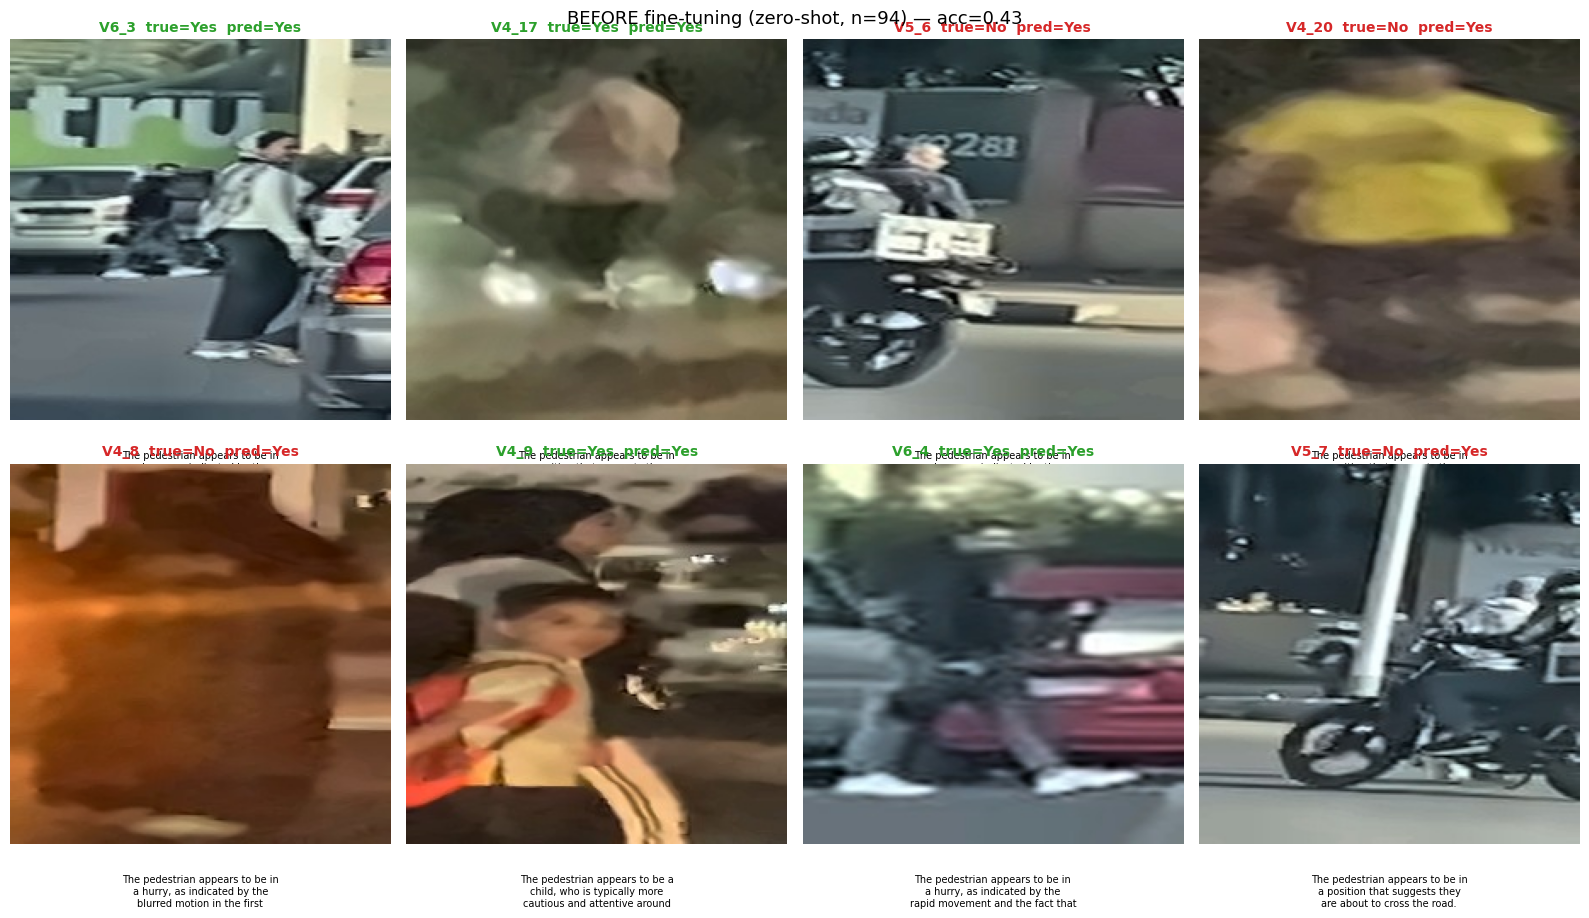

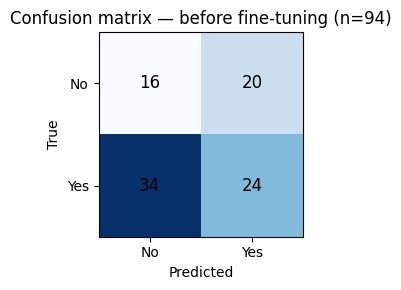

In [ ]:
def show_predictions(df_subset, y_true, y_pred, raws, title, n_show=8):
    # Only show real tracks in the montage (SYN rows only have 1 real image)
    real_mask = (df_subset['source'] == 'real').values
    df_real = df_subset[real_mask].reset_index(drop=True)
    idx_map = df_subset[real_mask].index
    y_true_real = [y_true[i] for i in idx_map]
    y_pred_real = [y_pred[i] for i in idx_map]
    raws_real   = [raws[i]   for i in idx_map]

    n_show = min(n_show, len(df_real))
    idxs = np.random.RandomState(SEED).choice(len(df_real), size=n_show, replace=False)
    n_cols = min(4, n_show)
    n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for slot, i in enumerate(idxs):
        row = df_real.iloc[i]
        paths = row['image_paths']
        mid_img = Image.open(paths[len(paths) // 2]).convert('RGB')
        ax = axes[slot]
        ax.imshow(mid_img)
        ax.axis('off')
        true_lbl = 'Yes' if y_true_real[i] else 'No'
        pred_lbl = 'Yes' if y_pred_real[i] else 'No'
        correct = y_true_real[i] == y_pred_real[i]
        color = '#2ca02c' if correct else '#d62728'
        conclusion = raws_real[i].split('FINAL_ANSWER:')[0].split('Conclusion:')[-1].strip()
        wrapped = '\n'.join(textwrap.wrap(conclusion, width=32)[:3])
        ax.set_title(f"{row['track_id']}  true={true_lbl}  pred={pred_lbl}",
                     color=color, fontsize=10, fontweight='bold')
        ax.text(0.5, -0.08, wrapped, transform=ax.transAxes, ha='center', va='top', fontsize=7)

    for j in range(len(idxs), len(axes)):
        axes[j].axis('off')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def show_confusion(y_true, y_pred, title, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(3.2, 3))
    ax.imshow(cm, cmap=cmap)
    for (r, c), v in np.ndenumerate(cm):
        ax.text(c, r, str(v), ha='center', va='center', fontsize=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['No', 'Yes']); ax.set_yticklabels(['No', 'Yes'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


show_predictions(df, labels_all, y_before, raw_before,
                  title=f'BEFORE fine-tuning (zero-shot, n={len(df)}) — acc={baseline_acc:.2f}')
show_confusion(labels_all, y_before, f'Confusion matrix — before fine-tuning (n={len(df)})')

## §10 — K-Fold Cross-Validated Fine-Tuning

Fresh model + LoRA adapter per fold, trained on `K-1` folds, evaluated on
the held-out fold, then freed before the next fold starts.

In [ ]:
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

oof_pred = np.full(len(df), -1, dtype=int)
oof_raw = [None] * len(df)
fold_id = np.full(len(df), -1, dtype=int)
fold_accuracies = []
reset_parse_stats()

for fold, (train_idx, test_idx) in enumerate(skf.split(df, df['label_bin'])):
    print('=' * 60)
    print(f' FOLD {fold + 1}/{K_FOLDS}  (train={len(train_idx)}, test={len(test_idx)})')
    print('=' * 60)

    df_fold_train = df.iloc[train_idx].reset_index(drop=True)
    df_fold_test = df.iloc[test_idx].reset_index(drop=True)
    fold_id[test_idx] = fold

    train_convs = df_to_train_convs(df_fold_train)
    test_convs = df_to_test_convs(df_fold_test)

    fold_model, fold_processor = build_finetunable_model()

    optimizer_steps = max((len(train_convs) // BATCH_SIZE // GRAD_ACCUM) * EPOCHS, 1)
    warmup_v = max(min(WARMUP_STEPS, optimizer_steps // 10), 1)

    training_args = TrainingArguments(
        output_dir=os.path.join(OUTPUT_DIR, f'fold_{fold}'),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type='cosine',
        logging_steps=max(optimizer_steps // 10, 1),
        save_strategy='no',
        max_grad_norm=MAX_GRAD_NORM,
        warmup_steps=warmup_v,
        gradient_accumulation_steps=GRAD_ACCUM,
        bf16=True,
        report_to=[],
        remove_unused_columns=False,
    )

    trainer = Trainer(
        model=fold_model,
        args=training_args,
        train_dataset=train_convs,
        data_collator=make_collate_fn(fold_processor),
    )
    trainer.train()

    fold_model.config.use_cache = True
    fold_model.eval()

    fold_preds = []
    for i, conv in zip(test_idx, test_convs):
        raw = run_inference(fold_model, fold_processor, conv)
        pred = parse_label(raw)
        oof_pred[i] = pred
        oof_raw[i] = raw
        fold_preds.append(pred)

    fold_true = df['label_bin'].iloc[test_idx].tolist()
    fold_acc = accuracy_score(fold_true, fold_preds)
    fold_accuracies.append(fold_acc)
    print(f"Fold {fold + 1} accuracy: {fold_acc:.3f}  ({sum(p == t for p, t in zip(fold_preds, fold_true))}/{len(fold_true)})")

    del trainer
    free_model(fold_model)

print('\n' + '=' * 60)
print(f' Per-fold accuracy: {[round(a, 3) for a in fold_accuracies]}')
print(f' Mean: {np.mean(fold_accuracies):.3f}   Std: {np.std(fold_accuracies):.3f}')
print('=' * 60)

 FOLD 1/5  (train=75, test=19)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


...

Fold 4 accuracy: 0.737  (14/19)
 FOLD 5/5  (train=76, test=18)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

Step,Training Loss
11,15.063628
22,8.849333
33,7.154105
44,6.983981
55,6.666962
66,6.791378
77,6.642036
88,6.602729


## §11 — Aggregated Out-of-Fold Evaluation (this cell was missing before)

Pools every fold's held-out predictions into one n-sized evaluation, then
breaks it down by `real` vs `synthetic` -- **check this breakdown before
trusting the pooled number.** If synthetic accuracy is far higher or lower
than real accuracy, the pooled figure is being distorted by a domain gap
between real and GPT-generated images, and the `real` row is the one to
trust.

In [ ]:
assert (oof_pred >= 0).all(), "every row should have exactly one out-of-fold prediction"

y_after = oof_pred.tolist()
raw_after = oof_raw

ft_acc = accuracy_score(labels_all, y_after)
ft_f1 = f1_score(labels_all, y_after, average='macro')
print(f"Cross-validated fine-tuned accuracy (n={len(df)}): {ft_acc:.3f}   F1 (macro): {ft_f1:.3f}")
print('\n' + classification_report(labels_all, y_after, target_names=['No', 'Yes']))
report_parse_stats('CV fine-tuned (out-of-fold)')

print('\n' + '=' * 60)
print(' Breakdown by data source (real photographs vs. GPT-augmented synthetic)')
print('=' * 60)
source_breakdown = {}
for src_name in ['real', 'synthetic']:
    mask = (df['source'] == src_name).values
    if mask.sum() == 0:
        continue
    y_true_src = np.array(labels_all)[mask]
    y_before_src = np.array(y_before)[mask]
    y_after_src = np.array(y_after)[mask]
    acc_before_src = accuracy_score(y_true_src, y_before_src)
    acc_after_src = accuracy_score(y_true_src, y_after_src)
    source_breakdown[src_name] = (acc_before_src, acc_after_src, int(mask.sum()))
    print(f"  {src_name:10s} (n={mask.sum():3d}):  before={acc_before_src:.3f}   after={acc_after_src:.3f}")

print("\nIf the 'real' and 'synthetic' rows differ a lot, treat the pooled")
print("number above with caution -- it's averaging two different domains.")

NameError: name 'oof_pred' is not defined

## §12 — After-Fine-Tuning Visualization (pooled out-of-fold predictions)

In [ ]:
show_predictions(df, labels_all, y_after, raw_after,
                  title=f'AFTER fine-tuning (5-fold CV, n={len(df)}) — acc={ft_acc:.2f}')
show_confusion(labels_all, y_after, f'Confusion matrix — after fine-tuning (n={len(df)})', cmap='Greens')

## §13 — Before vs After Comparison

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
metrics = ['Accuracy', 'F1 (macro)']
before_vals = [baseline_acc, baseline_f1]
after_vals = [ft_acc, ft_f1]
x = np.arange(len(metrics)); width = 0.35

ax.bar(x - width/2, before_vals, width, label=f'Before (zero-shot, n={len(df)})', color='#d62728')
ax.bar(x + width/2, after_vals, width, label=f'After (5-fold CV, n={len(df)})', color='#2ca02c')
ax.axhline(0.60, color='gray', linestyle='--', linewidth=1, label='Majority-class baseline (0.60, on original n=30)')
ax.axhline(0.667, color='gray', linestyle=':', linewidth=1, label='Attribute-only LR ceiling, LOO-CV (0.667, on original n=30)')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
for i, (b, a) in enumerate(zip(before_vals, after_vals)):
    ax.text(i - width/2, b + 0.02, f'{b:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, a + 0.02, f'{a:.2f}', ha='center', fontsize=9)
ax.set_title('Zero-shot vs cross-validated fine-tuned performance')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Per-fold accuracy: {[round(a, 3) for a in fold_accuracies]}")
print(f"Fold std dev: {np.std(fold_accuracies):.3f}")

In [ ]:
# Real vs synthetic, before vs after -- side by side
fig, ax = plt.subplots(figsize=(6, 4))
sources = list(source_breakdown.keys())
before_src = [source_breakdown[s][0] for s in sources]
after_src = [source_breakdown[s][1] for s in sources]
ns = [source_breakdown[s][2] for s in sources]
x = np.arange(len(sources)); width = 0.35

ax.bar(x - width/2, before_src, width, label='Before', color='#d62728')
ax.bar(x + width/2, after_src, width, label='After', color='#2ca02c')
ax.set_xticks(x); ax.set_xticklabels([f"{s}\n(n={n})" for s, n in zip(sources, ns)])
ax.set_ylim(0, 1.05)
for i, (b, a) in enumerate(zip(before_src, after_src)):
    ax.text(i - width/2, b + 0.02, f'{b:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, a + 0.02, f'{a:.2f}', ha='center', fontsize=9)
ax.set_title('Real vs. synthetic accuracy, before/after fine-tuning')
ax.legend()
plt.tight_layout()
plt.show()

## §14 — Save Results CSV

In [ ]:
rows = []
for i, row in df.iterrows():
    rows.append({
        'track_id': row['track_id'],
        'source': row['source'],
        'fold': int(fold_id[i]),
        'true_answer': row['answer'],
        'pred_before': 'Yes' if y_before[i] else 'No',
        'pred_after_oof': 'Yes' if y_after[i] else 'No',
        'correct_before': int(y_before[i] == row['label_bin']),
        'correct_after_oof': int(y_after[i] == row['label_bin']),
        'raw_before': raw_before[i],
        'raw_after_oof': raw_after[i],
    })
df_results = pd.DataFrame(rows)
out_path = os.path.join(OUTPUT_DIR, 'cv_results_before_after.csv')
df_results.to_csv(out_path, index=False)
print(f"Results saved → {out_path}")
df_results[['track_id', 'source', 'fold', 'true_answer', 'pred_before', 'pred_after_oof',
            'correct_before', 'correct_after_oof']]

## §15 — Train the Final Deployable Model (100% of data, optional)

Only run this once the `§11`/`§13` breakdown looks trustworthy enough to be
worth deploying.

In [ ]:
final_model, final_processor = build_finetunable_model()
final_train_convs = df_to_train_convs(df)  # 100% of the data, nothing held out

optimizer_steps = max((len(final_train_convs) // BATCH_SIZE // GRAD_ACCUM) * EPOCHS, 1)
warmup_v = max(min(WARMUP_STEPS, optimizer_steps // 10), 1)

final_args = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, 'final_full_data'),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type='cosine',
    logging_steps=max(optimizer_steps // 10, 1),
    save_strategy='no',
    max_grad_norm=MAX_GRAD_NORM,
    warmup_steps=warmup_v,
    gradient_accumulation_steps=GRAD_ACCUM,
    bf16=True,
    report_to=[],
    remove_unused_columns=False,
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=final_train_convs,
    data_collator=make_collate_fn(final_processor),
)
final_trainer.train()
print('Final full-data training complete ✓')

SAVE_TO_DRIVE = True
if SAVE_TO_DRIVE:
    drive_dest = '/content/drive/MyDrive/GIU.Master/qwen_pedestrianqa_egypt_final_adapter'
    final_model.save_pretrained(drive_dest)
    final_processor.save_pretrained(drive_dest)
    print(f"Final adapter saved → {drive_dest}")
else:
    final_model.save_pretrained(os.path.join(OUTPUT_DIR, 'final_full_data_adapter'))
    final_processor.save_pretrained(os.path.join(OUTPUT_DIR, 'final_full_data_adapter'))